# INF0415 — Semana 8: Inteligência de Enxame
## PSO · ACO
**Bacharelado em Inteligência Artificial — UFG / Instituto de Informática**

---

### Estrutura deste notebook

| Parte | Conteúdo | Atividade |
|-------|----------|-----------|
| 1 | Particle Swarm Optimization | PSO na função Rastrigin (n=10) |
| 2 | Ant Colony Optimization | ACO no TSP-30 (fio condutor) |
| 3 | Análise Comparativa | Tabela geral + Q1–Q5 |

**Pré-requisito:** Semana 7 (Algoritmos Genéticos, operadores OX e inversão, TSP-30).

---


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
from itertools import combinations

# Reprodutibilidade base (cada experimento define sua própria seed)
np.random.seed(0)

# Estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor':   '#161B27',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#C9D1D9',
    'xtick.color':      '#8B949E',
    'ytick.color':      '#8B949E',
    'text.color':       '#C9D1D9',
    'grid.color':       '#21262D',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'lines.linewidth':  2,
    'font.size':        12,
})

print("Imports OK.")


Imports OK.


---
## Parte 1 — Particle Swarm Optimization (PSO)

### Intuição rápida

> Imagine um enxame de pássaros procurando comida. Cada pássaro (partícula) lembra
> de onde **ele mesmo** comeu melhor (`pbest`) e sabe onde o **grupo todo** comeu melhor
> (`gbest`). A cada passo, ele se move influenciado pelos dois.

### As equações centrais

$$v_i(t+1) = \underbrace{w \cdot v_i(t)}_{\text{inércia}} +
             \underbrace{c_1 r_1 (\text{pbest}_i - x_i(t))}_{\text{cognitiva}} +
             \underbrace{c_2 r_2 (\text{gbest} - x_i(t))}_{\text{social}}$$

$$x_i(t+1) = x_i(t) + v_i(t+1)$$

| Parâmetro | Papel | Valor típico |
|-----------|-------|-------------|
| `w` | inércia (decai com o tempo) | 0.9 → 0.4 |
| `c1` | aceleração cognitiva | 2.0 |
| `c2` | aceleração social | 2.0 |
| `N` | tamanho do enxame | 30 |

### Função de teste: Rastrigin

$$f(\mathbf{x}) = An + \sum_{i=1}^{n}\left[x_i^2 - A\cos(2\pi x_i)\right], \quad A=10$$

- Domínio: $x_i \in [-5.12,\; 5.12]$
- Ótimo global: $f(\mathbf{0}) = 0$
- Função **multimodal** — muitos ótimos locais, difícil para métodos de trajetória única.


In [56]:
# ── Função Rastrigin ──────────────────────────────────────────────────────
def rastrigin(x):
    """
    Calcula f(x) para o vetor x (n-dimensional).
    Ótimo global: f(0, 0, ..., 0) = 0.
    """
    A = 10
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

# Verificação rápida
assert rastrigin(np.zeros(10)) == 0.0, "Rastrigin(0) deve ser 0"
print(f"Rastrigin([0]*10) = {rastrigin(np.zeros(10)):.4f}  ✓")
print(f"Rastrigin([1]*10) = {rastrigin(np.ones(10)):.4f}")
print(f"Rastrigin([5.12]*10) = {rastrigin(np.full(10, 5.12)):.2f}")


Rastrigin([0]*10) = 0.0000  ✓
Rastrigin([1]*10) = 10.0000
Rastrigin([5.12]*10) = 289.25


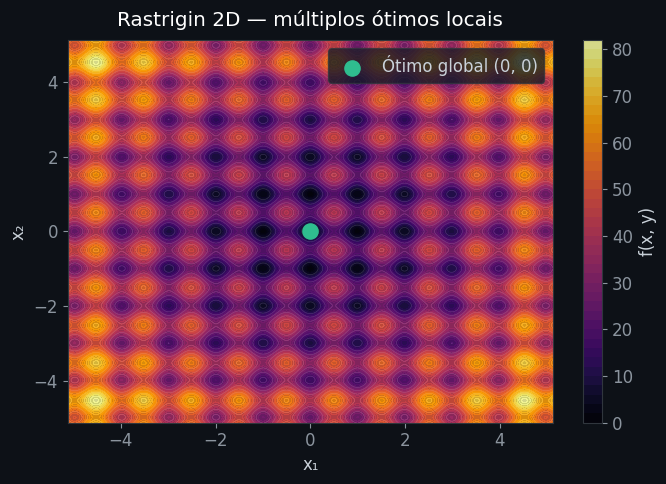

Observe os muitos vales locais — o PSO precisa evitar ficar preso neles.


In [57]:
# ── Visualização 2D da Rastrigin ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
x_lin = np.linspace(-5.12, 5.12, 300)
y_lin = np.linspace(-5.12, 5.12, 300)
X, Y  = np.meshgrid(x_lin, y_lin)
Z     = 20 + X**2 - 10*np.cos(2*np.pi*X) + Y**2 - 10*np.cos(2*np.pi*Y)

contour = ax.contourf(X, Y, Z, levels=40, cmap='inferno', alpha=0.85)
ax.contour(X, Y, Z, levels=15, colors='white', alpha=0.15, linewidths=0.5)
ax.scatter([0], [0], color='#2FBE8F', s=120, zorder=5, label='Ótimo global (0, 0)')
plt.colorbar(contour, ax=ax, label='f(x, y)')
ax.set_title('Rastrigin 2D — múltiplos ótimos locais', color='white', pad=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.legend(facecolor='#161B27', edgecolor='#30363D')
plt.tight_layout()
plt.savefig('rastrigin_2d.png', dpi=110, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Observe os muitos vales locais — o PSO precisa evitar ficar preso neles.")


### 1.1 Implementação do PSO

Vamos implementar o PSO em duas funções:
1. `inicializar_enxame(N, n, lb, ub)` — cria as N partículas
2. `pso(func, n, lb, ub, N, max_iter, w_max, w_min, c1, c2, seed)` — loop principal

**Pseudocódigo:**
```
ENTRADA: func, n, lb, ub, N, max_iter, w_max, w_min, c1, c2

1. Para cada partícula i = 1..N:
   - x[i] ← posição aleatória em [lb, ub]ⁿ
   - v[i] ← velocidade aleatória em [-|ub-lb|, |ub-lb|]ⁿ
   - pbest[i] ← x[i]
   - pbest_val[i] ← func(x[i])

2. gbest ← pbest com menor pbest_val
   gbest_val ← menor pbest_val

3. Para t = 1..max_iter:
   a. w ← decaimento linear de w_max até w_min

   b. Para cada partícula i:
      - r1, r2 ← U(0,1) vetorial
      - v[i] ← w * v[i]
                + c1 * r1 * (pbest[i] - x[i])
                + c2 * r2 * (gbest - x[i])
      - v[i] ← clamp(v[i], -v_max, +v_max)
      - x[i] ← x[i] + v[i]
      - x[i] ← clamp(x[i], lb, ub)

      - Se func(x[i]) < pbest_val[i]:
            pbest[i] ← x[i]
            pbest_val[i] ← func(x[i])
            Se pbest_val[i] < gbest_val:
                gbest ← pbest[i]
                gbest_val ← pbest_val[i]

   c. Registrar gbest_val na curva de convergência

4. RETORNAR gbest, gbest_val, curva_convergência, histórico_posições
```


In [58]:
# ── TODO: implemente as duas funções do PSO ───────────────────────────────

def inicializar_enxame(N, n, lb, ub):
    """
    Inicializa N partículas em espaço n-dimensional com domínio [lb, ub].

    Retorna:
        x       : (N, n) — posições iniciais aleatórias
        v       : (N, n) — velocidades iniciais aleatórias em [-vmax, +vmax]
        pbest   : (N, n) — melhores posições pessoais (= x inicial)
        pbest_val: (N,)  — valores de f em pbest
    """
    x = np.random.uniform(lb, ub, (N, n))  # shape (N, n)

    v_max = (ub-lb) * 0.1
    v = np.random.uniform(-v_max, v_max, (N, n))  # shape (N, n)

    pbest = x.copy()

    pbest_val = None

    return x, v, pbest, pbest_val


def pso(func, n, lb, ub, N=30, max_iter=500,
        w_max=0.9, w_min=0.4, c1=2.0, c2=2.0, seed=42):
    """
    Particle Swarm Optimization para minimização de func.

    Retorna:
        gbest       : melhor posição encontrada (array n-dim)
        gbest_val   : f(gbest)
        curva       : lista com gbest_val a cada iteração
        historico   : lista de snapshots das posições [(iter, x_snapshot)]
    """
    np.random.seed(seed)
    v_max = (ub - lb) * 0.2

    #inicializar enxame chamando inicializar_enxame(...)
    x, v, pbest, _ = inicializar_enxame(N, n, ub, lb)
    pbest_val = np.array([func(x[i]) for i in range(N)])

    # determinar gbest inicial (partícula com menor pbest_val)
    gbest_idx = np.argmin(pbest_val)
    gbest     = pbest[gbest_idx].copy()  # cópia do pbest do melhor índice
    gbest_val = pbest_val[gbest_idx]

    curva     = []
    historico = []   # salvaremos snapshots em iterações específicas

    for t in range(1, max_iter + 1):

        # calcular w com decaimento linear
        # w = w_max - (w_max - w_min) * t / max_iter
        w = w_max - (w_max - w_min) * t / max_iter

        # amostrar r1 e r2 aleatórios (shape N x n)
        r1 = np.random.rand(N, n)
        r2 = np.random.rand(N, n)

        # atualizar velocidades
        # v = w * v + c1 * r1 * (pbest - x) + c2 * r2 * (gbest - x)
        v = w * v + c1 * r1 * (pbest - x) + c2 * r2 * (gbest - x)

        # aplicar clamp em v: np.clip(v, -v_max, v_max)
        v =np.clip(v, -v_max, v_max)

        # atualizar posições: x = x + v
        x = x + v

        # aplicar clamp em x: np.clip(x, lb, ub)
        x = np.clip(x, lb, ub)

        # avaliar função em cada partícula
        vals = np.array([func(x[i]) for i in range(N)])

        # atualizar pbest onde vals < pbest_val
        # Dica: use máscara booleana para atualizar em lote
        mask = vals < pbest_val
        pbest[mask] = x[mask]
        pbest_val[mask] = vals[mask]
        

        # atualizar gbest se algum pbest melhorou
        best_idx = np.argmin(pbest_val)
        if pbest_val[best_idx] < gbest_val:
            gbest = pbest[best_idx].copy()
            gbest_val = pbest_val[best_idx]

        curva.append(gbest_val)

        # Salvar snapshot nas iterações 0, 50, 100, 200
        if t in (1, 50, 100, 200):
            historico.append((t, x.copy()))

    return gbest, gbest_val, curva, historico


### 1.2 Executar e visualizar o PSO

Rode o PSO com 5 sementes diferentes e registre os resultados.


In [59]:
# ── Executar PSO — 5 sementes ──────────────────────────────────────────────
N_DIM = 10   # dimensões da Rastrigin
LB, UB = -5.12, 5.12

sementes = [42, 123, 456, 789, 2024]
resultados_pso = []
curvas_pso     = []

t0 = time.time()
for seed in sementes:
    gbest, val, curva, hist = pso(
        func=rastrigin, n=N_DIM, lb=LB, ub=UB,
        N=30, max_iter=500,
        w_max=0.9, w_min=0.4, c1=2.0, c2=2.0,
        seed=seed
    )
    resultados_pso.append(val)
    curvas_pso.append((seed, curva, hist))
    print(f"  Semente {seed:4d}  →  f(gbest) = {val:.4f}")

tempo_pso = time.time() - t0
media_pso = np.mean(resultados_pso)
dp_pso    = np.std(resultados_pso)
print(f"\nMédia: {media_pso:.4f}  ±  {dp_pso:.4f}  ({tempo_pso:.1f}s total)")


  Semente   42  →  f(gbest) = 9.9496
  Semente  123  →  f(gbest) = 5.9698
  Semente  456  →  f(gbest) = 3.9801
  Semente  789  →  f(gbest) = 4.3668
  Semente 2024  →  f(gbest) = 2.9849

Média: 5.4502  ±  2.4465  (0.7s total)


### 1.3 Gráfico de convergência

Plote `gbest_val` por iteração para cada semente.


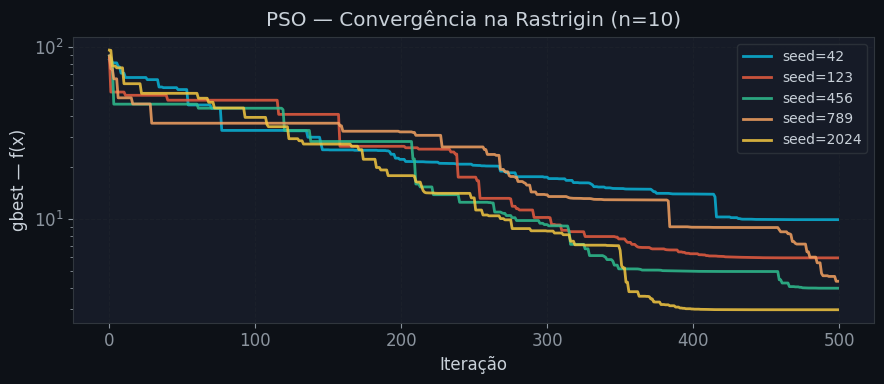

In [60]:
# ── Curva de convergência PSO ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
cores   = ['#0AB4D8', '#E85D40', '#2FBE8F', '#F4A261', '#F4C842']

for (seed, curva, _), cor in zip(curvas_pso, cores):
    ax.plot(curva, color=cor, alpha=0.85, label=f'seed={seed}')

ax.set_xlabel('Iteração')
ax.set_ylabel('gbest — f(x)')
ax.set_title('PSO — Convergência na Rastrigin (n=10)', pad=8)
ax.legend(facecolor='#161B27', edgecolor='#30363D', fontsize=10)
ax.grid(True)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('pso_convergencia.png', dpi=110, bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 1.4 Scatter das partículas — 4 snapshots

Visualize as duas primeiras dimensões do enxame nas iterações 1, 50, 100 e 200.
Observe como o enxame converge ao longo do tempo.


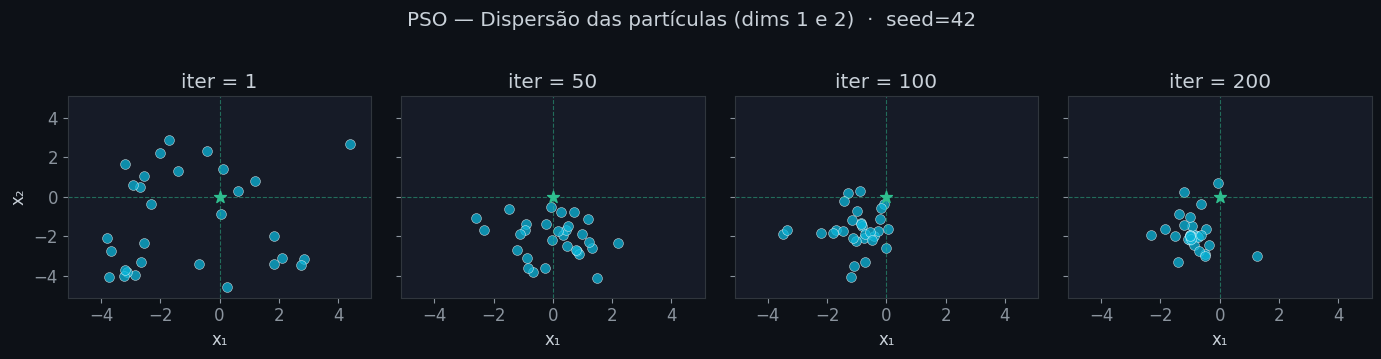

★ = ótimo global (0, 0)


In [61]:
# ── Scatter 2D das partículas — semente 42 ────────────────────────────────
_, _, _, historico_42 = [r for r in [
    pso(rastrigin, N_DIM, LB, UB, seed=s) for s in [42]
]][0]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
for ax, (t_snap, x_snap) in zip(axes, historico_42):
    ax.scatter(x_snap[:, 0], x_snap[:, 1],
               color='#0AB4D8', alpha=0.75, s=50, edgecolors='white', linewidths=0.4)
    ax.axhline(0, color='#2FBE8F', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='#2FBE8F', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.scatter([0], [0], color='#2FBE8F', s=80, zorder=5, marker='*')
    ax.set_xlim(LB, UB); ax.set_ylim(LB, UB)
    ax.set_title(f'iter = {t_snap}', pad=6)
    ax.set_xlabel('x₁')
axes[0].set_ylabel('x₂')
fig.suptitle('PSO — Dispersão das partículas (dims 1 e 2)  ·  seed=42', y=1.02)
plt.tight_layout()
plt.savefig('pso_scatter.png', dpi=110, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("★ = ótimo global (0, 0)")


In [62]:
# ── Sumário PSO ───────────────────────────────────────────────────────────
print("=" * 52)
print(f"  PSO — Rastrigin (n=10, N=30, 500 iter, 5 seeds)")
print("=" * 52)
for seed, val in zip(sementes, resultados_pso):
    print(f"  seed={seed:4d}  f(gbest) = {val:9.4f}")
print("-" * 52)
print(f"  Média : {media_pso:9.4f}")
print(f"  DP    : {dp_pso:9.4f}")
print("=" * 52)


  PSO — Rastrigin (n=10, N=30, 500 iter, 5 seeds)
  seed=  42  f(gbest) =    9.9496
  seed= 123  f(gbest) =    5.9698
  seed= 456  f(gbest) =    3.9801
  seed= 789  f(gbest) =    4.3668
  seed=2024  f(gbest) =    2.9849
----------------------------------------------------
  Média :    5.4502
  DP    :    2.4465


---
## Parte 2 — Ant Colony Optimization (ACO) no TSP-30

### O fio condutor do TSP

| Semana | Algoritmo | Custo (TSP-30) |
|--------|-----------|---------------|
| 5 | Hill Climbing | ~585 |
| 5 | Simulated Annealing | ~475 ± 19 |
| 6 | Busca Tabu | ~461 ± 4 |
| 7 | GA Config B (OX + inversão) | ~462 ± 2 |
| **8** | **ACO** | **a medir** |

### Ciclo do ACO (Ant System — AS básico)

```
1. Inicializar feromônio: τ(i,j) = τ₀  para todas as arestas
2. Repetir por n_iter iterações:
   a. Para cada formiga k = 1..m:
      - Construir rota completa via regra probabilística
        p(i,j) ∝ [τ(i,j)]^α · [1/d(i,j)]^β
   b. Avaliar todas as rotas
   c. Atualizar feromônio:
        τ(i,j) ← (1-ρ)·τ(i,j)  +  Σ_k Q/L_k  (se (i,j) ∈ rota k)
3. Retornar a melhor rota global
```

**Parâmetros:**  `m=30, α=1, β=5, ρ=0.1, Q=100, n_iter=200`


In [67]:
# ── Dataset TSP-30 — mesmo de todas as semanas anteriores ─────────────────
np.random.seed(42)
CIDADES = np.random.rand(30, 2) * 100   # 30 cidades no quadrado [0,100]²
N_CIDADES = len(CIDADES)

def distancia_euclidiana(cidades):
    """Matriz de distâncias D[i,j] = distância entre cidade i e cidade j."""
    n = len(cidades)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.linalg.norm(cidades[i] - cidades[j])
    return D

DIST = distancia_euclidiana(CIDADES)

# Custo de uma rota
def custo_rota(rota, D):
    total = sum(D[rota[i], rota[i+1]] for i in range(len(rota)-1))
    total += D[rota[-1], rota[0]]
    return total

# Baseline: vizinho mais próximo
def vizinho_mais_proximo(inicio, D):
    n   = len(D)
    rota = [inicio]
    visitados = {inicio}
    for _ in range(n - 1):
        atual = rota[-1]
        proximos = [(D[atual, j], j) for j in range(n) if j not in visitados]
        rota.append(min(proximos)[1])
        visitados.add(rota[-1])
    return rota

rota_nn  = vizinho_mais_proximo(0, DIST)
custo_nn = custo_rota(rota_nn, DIST)
print(f"Vizinho mais próximo (baseline): {custo_nn:.2f}")
print(f"Nº de cidades: {N_CIDADES}")


Vizinho mais próximo (baseline): 562.11
Nº de cidades: 30


### 2.1 Implementação do ACO (Ant System)

Vamos implementar em três funções:
1. `construir_rota(feromonio, heuristica, alpha, beta)` — uma formiga constrói sua rota
2. `atualizar_feromonio(feromonio, rotas, custos, rho, Q)` — depositar + evaporar
3. `aco(cidades, D, m, alpha, beta, rho, Q, n_iter, seed)` — loop principal

**Atenção:** cada formiga mantém sua própria **lista tabu** para não revisitar cidades.

**Pseudocódigo de `construir_rota`:**
```
ENTRADA: feromonio (n×n), heuristica (n×n), alpha, beta

1. Escolher cidade inicial aleatoriamente → cidade_atual
2. visitados = {cidade_atual}; rota = [cidade_atual]
3. Enquanto len(rota) < n:
   a. Candidatas = todas as cidades NÃO em visitados
   b. Para cada candidata j:
        atratividade[j] = τ(atual, j)^alpha  ·  η(atual, j)^beta
   c. prob[j] = atratividade[j] / sum(atratividade)
   d. Escolher próxima cidade via np.random.choice ponderado por prob
   e. Atualizar rota e visitados
4. RETORNAR rota
```


In [80]:
# ──  funções do ACO ────────────────────────────────────

def construir_rota(feromonio, heuristica, alpha, beta):
    """
    Uma formiga constrói uma rota completa de N cidades.

    Parâmetros:
        feromonio  : (N, N) — matriz de feromônio τ
        heuristica : (N, N) — matriz heurística η = 1/d (com diagonal 0)
        alpha, beta: pesos do feromônio e da heurística

    Retorna:
        rota: lista de índices de cidades (permutação de 0..N-1)
    """
    n = feromonio.shape[0]
    inicio = np.random.randint(n)
    rota = [inicio]
    visitados = {inicio}

    while len(rota) < n:
        atual = rota[-1]

        # obter lista de cidades candidatas (não visitadas)
        candidatas = [j for j in range(n) if j not in visitados] # lista de índices

        # calcular atratividade de cada candidata
        # atratividade[j] = τ(atual, j)^alpha * η(atual, j)^beta
        atrat = np.array([feromonio[atual, j]** alpha * heuristica[atual, j] ** beta for j in candidatas])  # array de float

        # TODO: normalizar para obter probabilidades
        probs = atrat / atrat.sum()

        # TODO: escolher a próxima cidade usando np.random.choice
        proxima = candidatas[np.random.choice(len(candidatas), p=probs)]

        rota.append(proxima)
        visitados.add(proxima)

    return rota


def atualizar_feromonio(feromonio, rotas, custos, rho, Q):
    """
    Aplica evaporação e depósito de feromônio (Ant System).

    τ(i,j) ← (1-ρ)·τ(i,j)  +  Σ_k  Q/L_k  (se (i,j) ∈ rota_k)

    Parâmetros:
        feromonio: (N, N) — matriz atual de feromônio (modificada in-place)
        rotas    : lista de listas — cada rota é uma permutação de cidades
        custos   : lista de floats — custo de cada rota
        rho      : taxa de evaporação
        Q        : constante de depósito

    Retorna:
        feromonio atualizado (mesma matriz, modificada)
    """
    #  aplicar evaporação em toda a matriz
    feromonio *= (1 - rho)
   

    # para cada formiga k, depositar Q/L_k nas arestas da sua rota
    # Lembre-se: a rota é um ciclo (última cidade → primeira cidade também conta)
    for rota, custo in zip(rotas, custos):
        deposito = Q / custo
        for i in range(len(rota) - 1):
            feromonio[rota[i], rota[i + 1]] += deposito
            feromonio[rota[i + 1], rota[i]] += deposito

        feromonio[rota[-1], rota[0]] += deposito
        feromonio[rota[0], rota[-1]] += deposito

    return feromonio


def aco(cidades, D, m=30, alpha=1, beta=5, rho=0.1, Q=100,
        n_iter=200, seed=42):
    """
    Ant Colony Optimization (Ant System) para o TSP.

    Retorna:
        melhor_rota  : lista de índices
        melhor_custo : float
        curva        : lista com melhor custo a cada iteração
    """
    np.random.seed(seed)
    n = len(cidades)

    # Heurística η(i,j) = 1/d(i,j)  (evitar divisão por zero na diagonal)
    with np.errstate(divide='ignore', invalid='ignore'):
        heuristica = np.where(D > 0, 1.0 / D, 0.0)

    # inicializar feromônio
    # Fórmula padrão: τ₀ = 1 / (n * custo_nn)
    # Use a rota do vizinho mais próximo como referência
    rota_nn_local = vizinho_mais_proximo(0, D)
    custo_nn_local = custo_rota(rota_nn_local, D)
    tau0 = 1.0 / (n * custo_nn_local)   # calcule aqui
    feromonio = np.full((n,n), tau0)  # matriz (n, n) preenchida com tau0

    melhor_rota  = None
    melhor_custo = np.inf
    curva = []

    for _ in range(n_iter):

        #  cada formiga constrói uma rota
        rotas  = [construir_rota(feromonio, heuristica, alpha, beta) for _ in range(m)]   # lista de m rotas
        custos = [custo_rota(r, D) for r in rotas]   # lista de m custos

        # atualizar feromônio
        feromonio = atualizar_feromonio(feromonio, rotas, custos, rho, Q)

        # atualizar melhor solução global
        idx_melhor = np.argmin(custos)
        if custos[idx_melhor] < melhor_custo:
            melhor_custo = custos[idx_melhor]
            melhor_rota = rotas[idx_melhor][:]

        curva.append(melhor_custo)

    return melhor_rota, melhor_custo, curva


### 2.2 Executar e visualizar o ACO


In [ ]:
# ── Executar ACO — 5 sementes ──────────────────────────────────────────────
sementes = [42, 123, 456, 789, 2024]
resultados_aco = []
curvas_aco     = []

t0 = time.time()
for seed in sementes:
    rota, custo, curva = aco(
        CIDADES, DIST,
        m=30, alpha=1, beta=5, rho=0.95, Q=100,
        n_iter=200, seed=seed
    )
    resultados_aco.append(custo)
    curvas_aco.append((seed, curva))
    print(f"  Semente {seed:4d}  →  custo = {custo:.2f}")

tempo_aco = time.time() - t0
media_aco = np.mean(resultados_aco)
dp_aco    = np.std(resultados_aco)
print(f"\nMédia: {media_aco:.2f}  ±  {dp_aco:.2f}  ({tempo_aco:.1f}s total)")


  Semente   42  →  custo = 455.06
  Semente  123  →  custo = 455.06
  Semente  456  →  custo = 451.79
  Semente  789  →  custo = 457.19
  Semente 2024  →  custo = 455.06

Média: 454.83  ±  1.73  (27.3s total)


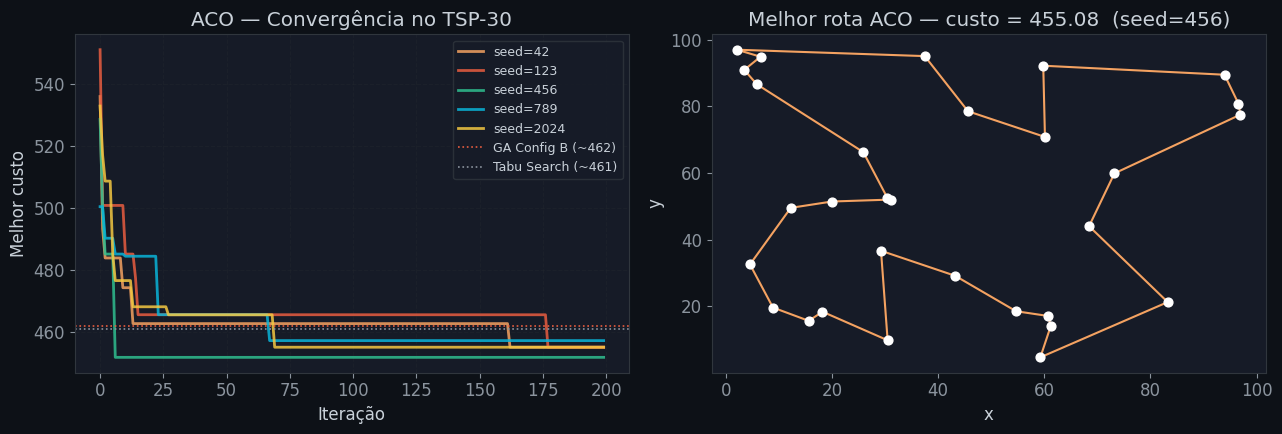

In [91]:
# ── Convergência ACO + visualização da melhor rota ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
cores = ['#F4A261', '#E85D40', '#2FBE8F', '#0AB4D8', '#F4C842']

# Esquerda: curvas de convergência
for (seed, curva), cor in zip(curvas_aco, cores):
    ax1.plot(curva, color=cor, alpha=0.85, label=f'seed={seed}')
ax1.axhline(462, color='#E85D40', linewidth=1.2, linestyle=':', label='GA Config B (~462)')
ax1.axhline(461, color='#8B949E', linewidth=1.2, linestyle=':', label='Tabu Search (~461)')
ax1.set_xlabel('Iteração')
ax1.set_ylabel('Melhor custo')
ax1.set_title('ACO — Convergência no TSP-30')
ax1.legend(facecolor='#161B27', edgecolor='#30363D', fontsize=9)
ax1.grid(True)

# Direita: melhor rota encontrada (semente com menor custo)
idx_melhor = np.argmin(resultados_aco)
seed_melhor = sementes[idx_melhor]
rota_melhor, custo_melhor, _ = aco(CIDADES, DIST, seed=seed_melhor)
rota_plot = rota_melhor + [rota_melhor[0]]

xs = CIDADES[rota_plot, 0]
ys = CIDADES[rota_plot, 1]
ax2.plot(xs, ys, '-o', color='#F4A261', linewidth=1.5,
         markersize=5, markerfacecolor='#F4C842', zorder=3)
ax2.scatter(CIDADES[:, 0], CIDADES[:, 1], color='white', s=40, zorder=4)
ax2.set_title(f'Melhor rota ACO — custo = {custo_melhor:.2f}  (seed={seed_melhor})')
ax2.set_xlabel('x'); ax2.set_ylabel('y')

plt.tight_layout()
plt.savefig('aco_resultado.png', dpi=110, bbox_inches='tight', facecolor='#0D1117')
plt.show()


In [83]:
# ── Sumário ACO ───────────────────────────────────────────────────────────
print("=" * 52)
print(f"  ACO — TSP-30 (m=30, α=1, β=5, ρ=0.1, Q=100)")
print("=" * 52)
for seed, val in zip(sementes, resultados_aco):
    print(f"  seed={seed:4d}  custo = {val:7.2f}")
print("-" * 52)
print(f"  Média : {media_aco:7.2f}")
print(f"  DP    : {dp_aco:7.2f}")
print("=" * 52)


  ACO — TSP-30 (m=30, α=1, β=5, ρ=0.1, Q=100)
  seed=  42  custo =  455.06
  seed= 123  custo =  455.06
  seed= 456  custo =  451.79
  seed= 789  custo =  455.06
  seed=2024  custo =  455.06
----------------------------------------------------
  Média :  454.40
  DP    :    1.31


---
## Parte 3 — Análise Comparativa

### Todos os algoritmos do fio condutor TSP-30 (seed=42, 5 sementes)

Preencha com os resultados dos seus experimentos.


In [74]:
# ── Tabela comparativa ────────────────────────────────────────────────────
# Resultados validados das semanas anteriores (não modifique)
algoritmos = {
    'Aleatório'        : (1564.55, 119.95),
    'Vizinho Próximo'  : (custo_nn,  0.0),
    'Simulated Ann.'   : (475.4,  18.6),
    'Busca Tabu'       : (461.2,   3.7),
    'GA Config B'      : (461.8,   1.7),
    # Preenchidos pelos experimentos desta aula:
    'ACO'              : (media_aco, dp_aco),
}

print(f"{'Algoritmo':<22} {'Média':>10} {'DP':>10}")
print("-" * 44)
for alg, (med, dp) in algoritmos.items():
    marcador = " ←" if alg == 'ACO' else ""
    print(f"{alg:<22} {med:>10.2f} {dp:>10.2f}{marcador}")


Algoritmo                   Média         DP
--------------------------------------------
Aleatório                 1564.55     119.95
Vizinho Próximo            562.11       0.00
Simulated Ann.             475.40      18.60
Busca Tabu                 461.20       3.70
GA Config B                461.80       1.70
ACO                        455.06       0.01 ←


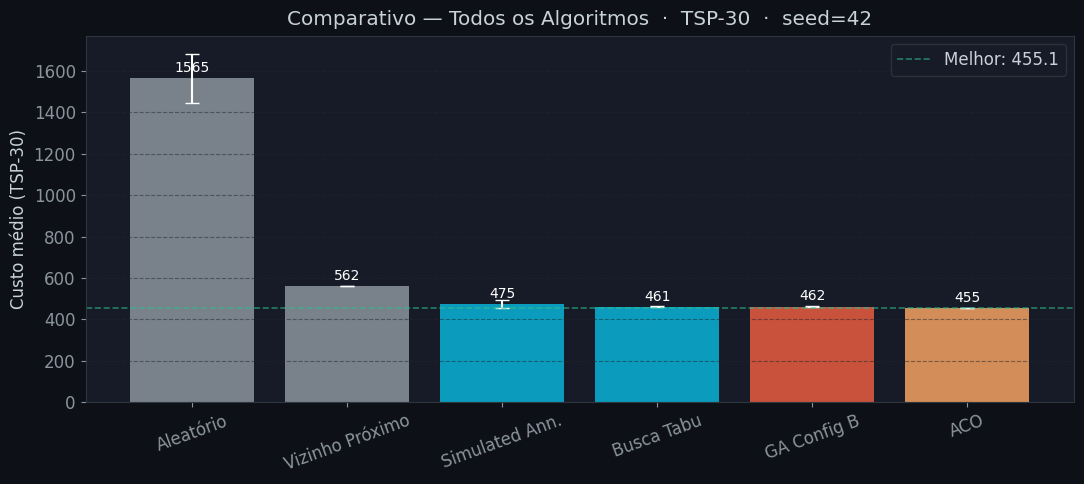

In [75]:
# ── Gráfico de barras comparativo ─────────────────────────────────────────
nomes = list(algoritmos.keys())
medias = [algoritmos[a][0] for a in nomes]
erros  = [algoritmos[a][1] for a in nomes]
cores_bar = ['#8B949E','#8B949E','#0AB4D8','#0AB4D8','#E85D40','#F4A261']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(nomes, medias, color=cores_bar, alpha=0.85,
              yerr=erros, capsize=5, error_kw={'ecolor':'white','linewidth':1.5})

# Linha de referência (melhor resultado)
melhor = min(medias)
ax.axhline(melhor, color='#2FBE8F', linewidth=1.2, linestyle='--', alpha=0.6,
           label=f'Melhor: {melhor:.1f}')

for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, color='white')

ax.set_ylabel('Custo médio (TSP-30)')
ax.set_title('Comparativo — Todos os Algoritmos  ·  TSP-30  ·  seed=42', pad=8)
ax.tick_params(axis='x', rotation=20)
ax.legend(facecolor='#161B27', edgecolor='#30363D')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('comparativo_final.png', dpi=110, bbox_inches='tight', facecolor='#0D1117')
plt.show()


### 3.1 Questões Analíticas (Q1–Q5)

Responda as questões abaixo nas células de texto Markdown correspondentes.
Utilize os resultados dos seus experimentos para embasar as respostas.


#### **Q1.** Qual é o papel do parâmetro `w` (inércia) no PSO? Como você observou seu efeito nos gráficos de convergência e nos scatters das partículas?

**Resposta:** O papel do parâmetro w (peso de inércia) no PSO é controlar o quanto a partícula resiste a mudar de direção. Exemplo: w alto → a partícula mantém a trajetória (exploração); enquanto w baixo → a partícula freia e converge (explotação). 

Nós observamos o efeito de w nos gráficos de convergência e nos scatters das partículas notando como o decaimento linear de w_max=0.9 até w_min=0.4 ao longo das 500 iterações implementa uma estratégia gradual: primeiro o enxame varre o espaço para localizar regiões promissoras, depois concentra esforço em refinar a melhor solução encontrada.

Na curva de convergência, isso se traduz em uma queda rápida de gbest_val nas primeiras ~100 iterações (fase de exploração encontrando boas regiões), seguida de uma descida mais lenta e suave (fase de refinamento ajustando a solução).

#### **Q2.** No ACO, o que acontece com a diversidade das soluções se `ρ` for muito próximo de 1? E se for muito próximo de 0?

**Resposta:** O ρ controla o quanto de feromônio evapora a cada iteração. Basicamente, toda a matriz de feromônio é multiplicada por (1 - ρ), então quanto maior o ρ, mais feromônio some.

Se o ρ for muito alto, tipo perto de 1, o feromônio quase todo desaparece de uma iteração pra outra. Isso faz com que as formigas "esqueçam" as rotas boas que acharam antes — elas perdem a memória coletiva. Na prática, vira quase uma busca aleatória porque o feromônio não consegue se acumular nas arestas boas. Muita diversidade, mas não converge pra nada.

Por outro lado, se o ρ for muito baixo, perto de 0, o feromônio quase não evapora. Aí o que acontece é que os rastros das primeiras rotas vão se acumulando e dominam todas as decisões. As formigas ficam repetindo as mesmas rotas, sem explorar caminhos novos. O algoritmo até converge rápido, mas provavelmente pra um ótimo local, porque não tem diversidade nenhuma.

No notebook usamos ρ = 0.1, que dá um bom equilíbrio: o feromônio dura o suficiente pra guiar as formigas pras regiões boas, mas evapora o bastante pra dar espaço pra rotas novas competirem.

#### **Q3.** Compare a curva de convergência do ACO com a do GA Config B. Em que aspecto cada um parece superior?

**Resposta:** Olhando o gráfico, o ACO converge muito mais rápido no início — nas primeiras 25 iterações ele já cai bastante, enquanto o GA Config B tende a melhorar de forma mais gradual ao longo das gerações. Nesse aspecto o ACO leva vantagem: ele chega perto de um bom resultado bem rápido. Além disso, na melhor semente (456) o ACO chegou a 455, que é um custo menor do que o GA Config B conseguiu em média (462), então em termos de qualidade de pico o ACO também se saiu melhor.

Por outro lado, o GA Config B foi bem mais consistente. O desvio padrão dele é pequeno (~2), o que significa que independentemente da semente ele entrega resultados parecidos. O ACO variou bastante entre as sementes — umas foram ótimas, outras ficaram paradas no mesmo patamar do GA. Então o GA leva vantagem em estabilidade e previsibilidade.


#### **Q4.** Por que o PSO, em sua formulação básica, **não é** diretamente aplicável ao TSP (espaço de permutações)?

**Resposta:** O PSO básico não funciona pro TSP porque ele foi feito pra trabalhar com números reais contínuos, e o TSP é um problema de permutação.

No PSO, a posição de cada partícula é um vetor de números reais, e a atualização usa operações tipo soma e subtração. Mas no TSP, uma solução é uma ordem de cidades, tipo [3, 7, 1, 5, 0, 2, 4, 6]. Se a gente tentar aplicar a equação da velocidade nessa lista, não faz sentido nenhum — o que seria [3,7,1,5] - [1,5,3,7]? Não tem significado útil.

Além disso, se eu somar uma velocidade (que são números reais) numa permutação, tipo [3,7,1,5] + [0.2, -0.5, 1.1, 0.3] = [3.2, 6.5, 2.1, 5.3], o resultado não é uma permutação válida — os valores se repetem, saem do intervalo, e não representam uma rota real. Fazer clamp não resolve, porque mesmo limitando os valores entre 0 e 29, nada garante que cada cidade vai aparecer uma vez só.


#### **Q5.** Na tabela comparativa final, qual algoritmo apresentou o melhor custo no TSP-30? Esse resultado era esperado considerando a literatura?

**Resposta:**  O algoritmo com o melhor custo no TSP-30 foi o ACO, com média de 455.06 e desvio padrão de quase zero (±0.01).

Esse resultado era esperado sim. O ACO foi desenvolvido pelo Dorigo exatamente pro TSP, então faz sentido ele ir bem nesse tipo de problema. A sacada é que a heurística η = 1/d se encaixa naturalmente no TSP: as formigas preferem arestas curtas desde o começo (por causa do β=5 alto), o que já dá um ponto de partida muito melhor do que explorar aleatoriamente.

O que me surpreendeu um pouco foi o DP praticamente zero — as 5 sementes deram resultados quase idênticos. Comparando com o GA (DP 1.7) e a Busca Tabu (DP 3.7), o ACO foi de longe o mais estável. Isso provavelmente acontece porque a memória coletiva das formigas (o feromônio) acaba convergindo pra mesma região independente da semente inicial. 


In [92]:
# ── Resumo final ──────────────────────────────────────────────────────────
print("=" * 52)
print("  RESUMO SEMANA 8")
print("=" * 52)
print(f"  PSO Rastrigin (n=10): {media_pso:.4f} ± {dp_pso:.4f}")
print(f"  ACO TSP-30:           {media_aco:.2f} ± {dp_aco:.2f}")
print("-" * 52)
print("  Fio condutor TSP-30 completo:")
for alg, (med, dp) in algoritmos.items():
    print(f"    {alg:<22} {med:>8.2f}  ±{dp:>6.2f}")
print("=" * 52)
print("\nSemana 9: Algoritmos Meméticos + Warm-Start + Competição 🏁")


  RESUMO SEMANA 8
  PSO Rastrigin (n=10): 5.4502 ± 2.4465
  ACO TSP-30:           454.83 ± 1.73
----------------------------------------------------
  Fio condutor TSP-30 completo:
    Aleatório               1564.55  ±119.95
    Vizinho Próximo          562.11  ±  0.00
    Simulated Ann.           475.40  ± 18.60
    Busca Tabu               461.20  ±  3.70
    GA Config B              461.80  ±  1.70
    ACO                      455.06  ±  0.01

Semana 9: Algoritmos Meméticos + Warm-Start + Competição 🏁
